# Membrane Protein Data - Data Analysis

## Objectives

* Explore the cleaned membrane protein dataset and identify biologically meaningful patterns.
* Investigate the distribution of membrane protein structures across membrane types, protein families, and species.
* Analyse structural properties including membrane thickness, protein tilt, number of transmembrane segments, and structure resolution.
* Explore relationships between structural and membrane-related variables using appropriate visualisations.
* Identify trends and observations that address the project's research questions.

## Inputs

* `data/proteins_cleaned.csv` — cleaned membrane protein dataset generated in `01_data_cleaning.ipynb`.

## Outputs

* Summary statistics describing the membrane protein dataset.
* Visualisations of important categorical and numerical variables.
* Analysis of relationships between membrane environment and structural properties.
* Biological interpretation of the main patterns observed in the dataset.

## Additional Comments

* Data cleaning and validation were performed separately in `01_data_cleaning.ipynb`.
* Missing values retained during data cleaning will be handled appropriately for each individual analysis rather than being artificially imputed.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

In [2]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\trasn\\OneDrive\\Dokumente\\programing\\37 week-app\\membrane-protein-data-analysis\\jupyter_notebooks'

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\trasn\\OneDrive\\Dokumente\\programing\\37 week-app\\membrane-protein-data-analysis'

In [5]:
os.path.exists("data/proteins_cleaned.csv")

True


# Load Cleaned Dataset

The cleaned membrane protein dataset generated during the data cleaning stage is loaded for exploratory data analysis and visualisation.

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/proteins_cleaned.csv")

df.head()

,id,ordering,family_name_cache,species_name_cache,membrane_name_cache,name,pdbid,resolution,topology_subunit,topology_show_in,...,superfamily_id,classtype_id,type_id,secondary_representations_count,structure_subunits_count,citations_count,created_at,updated_at,uniprotcode,resolution_numeric
0,1,6024.0,OmpA family,Escherichia coli,Gram-neg. outer,"Outer membrane protein A (OMPA), disordered loops",1qjp,1.65,A,True,...,26,2,1,3,1,2,2018-08-13 03:49:46 UTC,2023-02-22 20:43:56 UTC,OMPA_ECOLI,1.65
1,2,6027.0,Enterobacterial Ail/Lom protein,Escherichia coli,Gram-neg. outer,Outer membrane protein X (OMPX),1qj8,1.9,A,True,...,26,2,1,7,1,1,2018-08-13 03:49:46 UTC,2023-02-22 20:43:57 UTC,OMPX_ECOLI,1.90
2,3,6032.0,Opacity porins,Neisseria meningitidis,Gram-neg. outer,Outer membrane protein NspA,1p4t,2.55,A,True,...,235,2,1,0,1,0,2018-08-13 03:49:46 UTC,2023-02-22 20:43:57 UTC,Q9RP17_NEIME,2.55
3,4,5624.0,Influenza virus matrix protein 2,Influenza A virus,Viral,"M2 proton channel of Influenza A, closed state...",3lbw,1.65,A,False,...,185,11,1,3,4,0,2018-08-13 03:49:46 UTC,2023-02-22 20:43:54 UTC,M2_I97A1,1.65
4,5,6047.0,"OM protease omptin, OMPT",Yersinia pestis,Gram-neg. outer,Plasminogen activator PLA (coagulase/fibrinoly...,2x55,1.85,A,True,...,27,2,1,2,1,0,2018-08-13 03:49:46 UTC,2023-02-22 20:43:56 UTC,COLY_YERPE,1.85


---

# Section 1: Exploratory Data Analysis

The cleaned membrane protein dataset will be explored to identify patterns in membrane environments, structural properties, and protein groups. The analysis will focus on a small number of biologically relevant questions so that each visualisation directly supports a specific objective.

# Dataset Overview

This section provides an overview of the cleaned membrane protein dataset before exploratory analysis.

The dataset contains membrane-associated protein structures together with information about their membrane environment, protein family, species, structural resolution, membrane thickness, tilt, and number of membrane-spanning segments.

In [7]:
df.shape

(8914, 29)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914 entries, 0 to 8913
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               8914 non-null   int64  
 1   ordering                         8914 non-null   float64
 2   family_name_cache                8914 non-null   object 
 3   species_name_cache               8914 non-null   object 
 4   membrane_name_cache              8914 non-null   object 
 5   name                             8914 non-null   object 
 6   pdbid                            8914 non-null   object 
 7   resolution                       8878 non-null   object 
 8   topology_subunit                 6652 non-null   object 
 9   topology_show_in                 8914 non-null   bool   
 10  thickness                        8914 non-null   float64
 11  thicknesserror                   8879 non-null   float64
 12  subunit_segments    

In [9]:
df.describe()

,id,ordering,thickness,thicknesserror,subunit_segments,tilt,tilterror,gibbs,membrane_id,species_id,family_id,superfamily_id,classtype_id,type_id,secondary_representations_count,structure_subunits_count,citations_count,resolution_numeric
count,8914.000000,8914.000000,8914.000000,8879.000000,8914.000000,8914.000000,8885.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,7575.000000
mean,4976.168050,4457.726946,22.220989,1.242876,14.134283,23.621943,3.440293,-89.151604,7.728180,168.053175,402.522661,115.446152,2.869531,1.359996,0.892753,3.020305,0.039601,3.064330
std,3127.684077,2573.698390,12.084034,2.387488,18.642546,30.730578,12.668511,88.522280,6.727805,263.559076,369.250690,144.131484,3.019612,0.635338,4.620690,5.572863,0.347939,1.262766
min,1.000000,1.000000,0.000000,-3.000000,0.000000,0.000000,-4.000000,-691.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.540000
25%,2291.250000,2229.250000,6.500000,0.600000,0.000000,1.000000,0.000000,-126.900000,4.000000,14.000000,60.000000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.440000
50%,4575.500000,4457.500000,29.650000,1.000000,10.000000,7.000000,1.000000,-71.550000,4.000000,36.000000,278.000000,50.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000
75%,8103.750000,6685.750000,31.000000,1.500000,21.000000,44.000000,4.000000,-9.600000,9.000000,213.000000,724.000000,179.000000,4.000000,2.000000,0.000000,4.000000,0.000000,3.500000
max,10363.000000,8915.000000,41.800000,180.000000,389.000000,91.000000,1039.000000,165.500000,24.000000,1150.000000,1240.000000,607.000000,11.000000,3.000000,132.000000,70.000000,11.000000,37.000000


### Dataset Overview Summary

The cleaned dataset contains 8,914 observations and 29 variables. It includes both categorical information describing the proteins and their biological context, and numerical measurements describing structural and membrane-related properties.

The following exploratory analysis focuses on variables that are most relevant to the biological questions of the project.

# Section 2 - Exploratory data analysis

The exploratory analysis investigates patterns in membrane environments, protein families, structural properties, and membrane protein complexity.

## Research Questions

1. Which membrane environments and protein families are most represented in the dataset?
2. How do structural properties such as membrane thickness, tilt, and resolution differ between membrane environments?
3. Is structural complexity, represented by the number of membrane-spanning segments, associated with structural resolution?
4. Which numerical structural properties show meaningful relationships with each other?

## 2.1 Representation of Membrane Environments and Protein Families

The first research question examines which membrane environments and protein families are most represented in the dataset.

Understanding the distribution of entries across these categories provides context for the subsequent analyses and helps identify potential imbalances in the dataset.

In [10]:
membrane_counts = df["membrane_name_cache"].value_counts()

membrane_counts

membrane_name_cache
Eykaryo. plasma         3316
Secreted                1359
Gram-neg. inner         1251
Endoplasm. reticulum     548
Gram-neg. outer          421
Gram-pos. inner          374
Mitochon. inner          347
Thylakoid                192
Undefined                185
Archaebac.               179
Viral                    176
Lysosome                 102
Golgi                    102
Endosome                  97
Vacuole                   82
Mitochon. outer           69
Vesicle                   42
Peroxisome                27
Nuclear outer             16
Gram-pos. outer           10
Chloroplast inner          7
Nuclear inner              6
Chloroplast outer          4
Granule                    2
Name: count, dtype: int64

In [11]:
family_counts = df["family_name_cache"].value_counts()

family_counts.head(15)

family_name_cache
G-protein coupled receptors, family A                     664
Transient receptor potential channels                     254
V-type and F-type ATPases                                 193
H+ or Na+ translocating NADH dehydrogenase                177
Glutamate-gated Ion Channel (GIC) family                  137
GPCR Secretin (B) family                                  135
P-ATPase                                                  133
Ligand-gated ion channel of neurotransmitter receptors    126
Cytochrome P450                                           122
Voltage-gated calcium and sodium channels                  95
Microbial and algal rhodopsins                             85
OMP insertion (Bam complex) porin (n=16,S=22)              80
Proton glutamate symport protein                           79
Photosystem I                                              71
Vertebrate secretory phospholipase A2                      69
Name: count, dtype: int64

### 2.1.1 Membrane Environment Distribution

The number of protein structures associated with each membrane environment was examined to determine which environments are most represented in the dataset.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


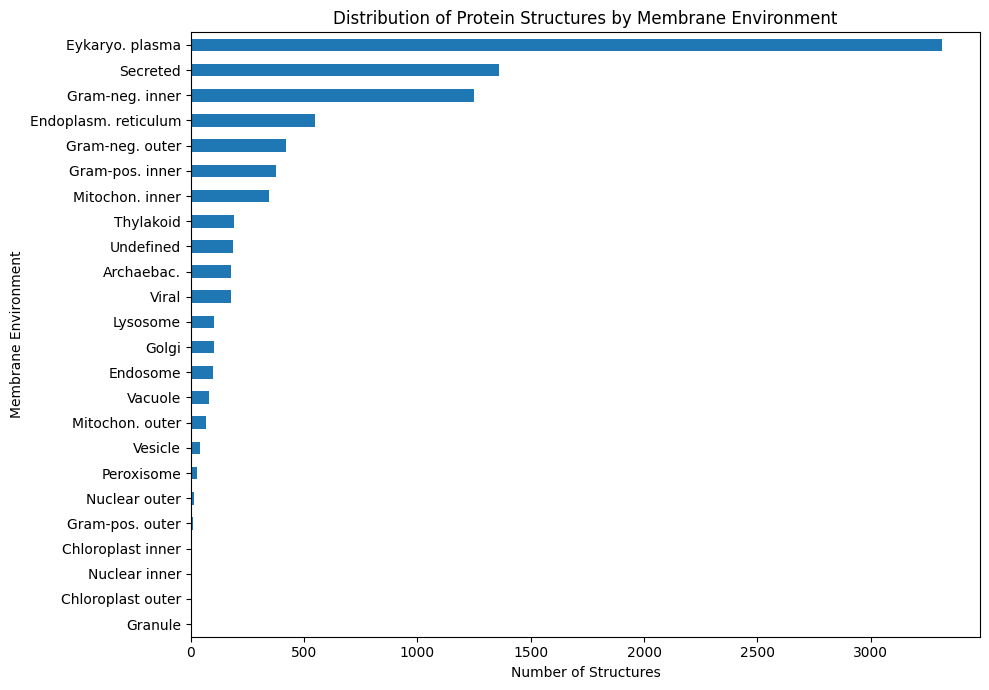

In [15]:
plt.figure(figsize=(10, 7))

membrane_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Protein Structures by Membrane Environment")
plt.xlabel("Number of Structures")
plt.ylabel("Membrane Environment")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of membrane environments is strongly uneven. Eukaryotic plasma membrane proteins represent the largest group in the dataset, with 3,316 structures, followed by secreted proteins (1,359) and Gram-negative inner membrane proteins (1,251).

Together, these three categories account for approximately 66.5% of all structures in the dataset. In contrast, several membrane environments, including nuclear and chloroplast membranes, contain relatively few observations.

This imbalance should be considered when interpreting comparisons between membrane environments, since patterns observed in highly represented groups may be more robust than those based on categories with only a small number of structures.

### 2.1.2 Most Represented Protein Families

The distribution of protein families was examined to identify which families contribute the largest number of structures to the dataset.

In [16]:
family_counts = df["family_name_cache"].value_counts()

family_counts.head(15)

family_name_cache
G-protein coupled receptors, family A                     664
Transient receptor potential channels                     254
V-type and F-type ATPases                                 193
H+ or Na+ translocating NADH dehydrogenase                177
Glutamate-gated Ion Channel (GIC) family                  137
GPCR Secretin (B) family                                  135
P-ATPase                                                  133
Ligand-gated ion channel of neurotransmitter receptors    126
Cytochrome P450                                           122
Voltage-gated calcium and sodium channels                  95
Microbial and algal rhodopsins                             85
OMP insertion (Bam complex) porin (n=16,S=22)              80
Proton glutamate symport protein                           79
Photosystem I                                              71
Vertebrate secretory phospholipase A2                      69
Name: count, dtype: int64

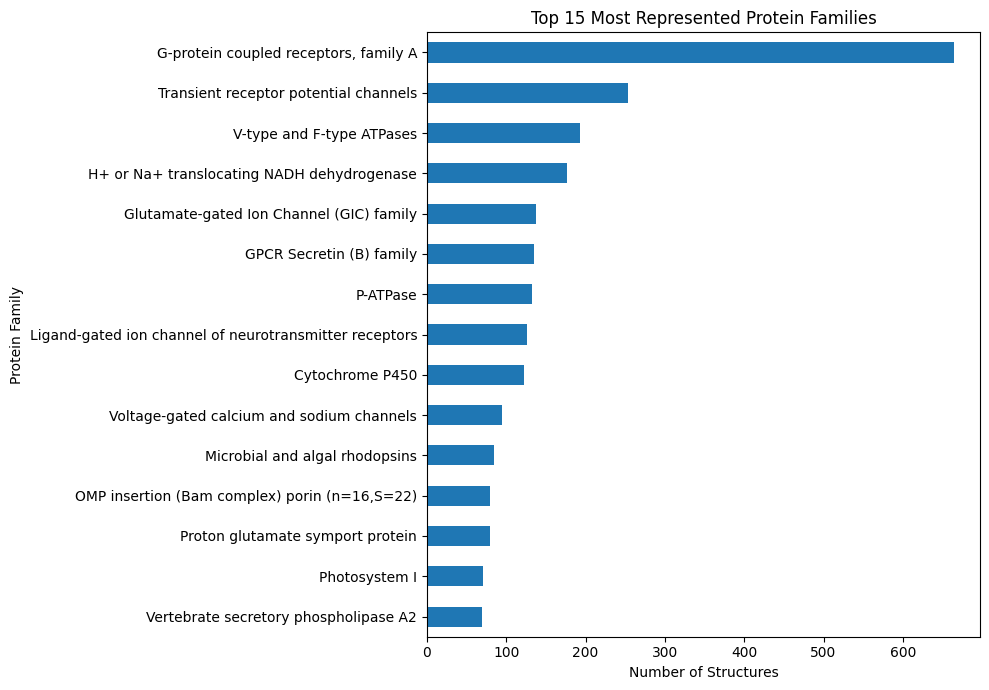

In [17]:
top_families = family_counts.head(15)

plt.figure(figsize=(10, 7))

top_families.sort_values().plot(kind="barh")

plt.title("Top 15 Most Represented Protein Families")
plt.xlabel("Number of Structures")
plt.ylabel("Protein Family")

plt.tight_layout()
plt.show()

### Interpretation

The protein-family distribution is also uneven. G-protein coupled receptors (GPCRs), family A, are the most represented family in the dataset, with 664 structures, substantially more than the second most represented group, transient receptor potential channels, with 254 structures.

Several other major membrane-protein groups are well represented, including V-type and F-type ATPases, respiratory complex I-related NADH dehydrogenases, ion channels, P-type ATPases, and cytochrome P450 proteins.

The strong representation of GPCRs and other extensively studied membrane-protein families indicates that the dataset reflects differences in structural research coverage. Therefore, the number of structures in a family should not be interpreted as the biological abundance of that protein family.

### Research Question 1 Summary

The dataset is dominated by a relatively small number of membrane environments and protein families. Eukaryotic plasma membrane proteins are the most represented membrane environment, while family A GPCRs are the most represented protein family. This uneven representation will be considered when comparing structural properties between groups in subsequent analyses.

## 2.2 Structural Properties Across Membrane Environments

The second research question examines whether membrane-protein structural properties differ between membrane environments.

The analysis focuses on membrane thickness, protein tilt, and structural resolution. Since the dataset contains 24 membrane environments with highly unequal representation, comparisons are restricted to the 10 most represented environments. This improves visual readability and reduces the influence of categories represented by only a small number of structures.

Missing values are not imputed. Instead, records with missing values are excluded only from the specific analysis requiring that variable.

In [18]:
top_10_membranes = (
    df["membrane_name_cache"]
    .value_counts()
    .head(10)
    .index
)

top_10_membranes

Index(['Eykaryo. plasma', 'Secreted', 'Gram-neg. inner',
       'Endoplasm. reticulum', 'Gram-neg. outer', 'Gram-pos. inner',
       'Mitochon. inner', 'Thylakoid', 'Undefined', 'Archaebac.'],
      dtype='object', name='membrane_name_cache')

In [19]:
df_top_membranes = df[
    df["membrane_name_cache"].isin(top_10_membranes)
].copy()

df_top_membranes.shape

(8172, 29)

### 2.2.1 Membrane Thickness

Membrane thickness is compared across the 10 most represented membrane environments. Box plots are used because they show the median, interquartile range, overall spread, and potential extreme observations within each group.

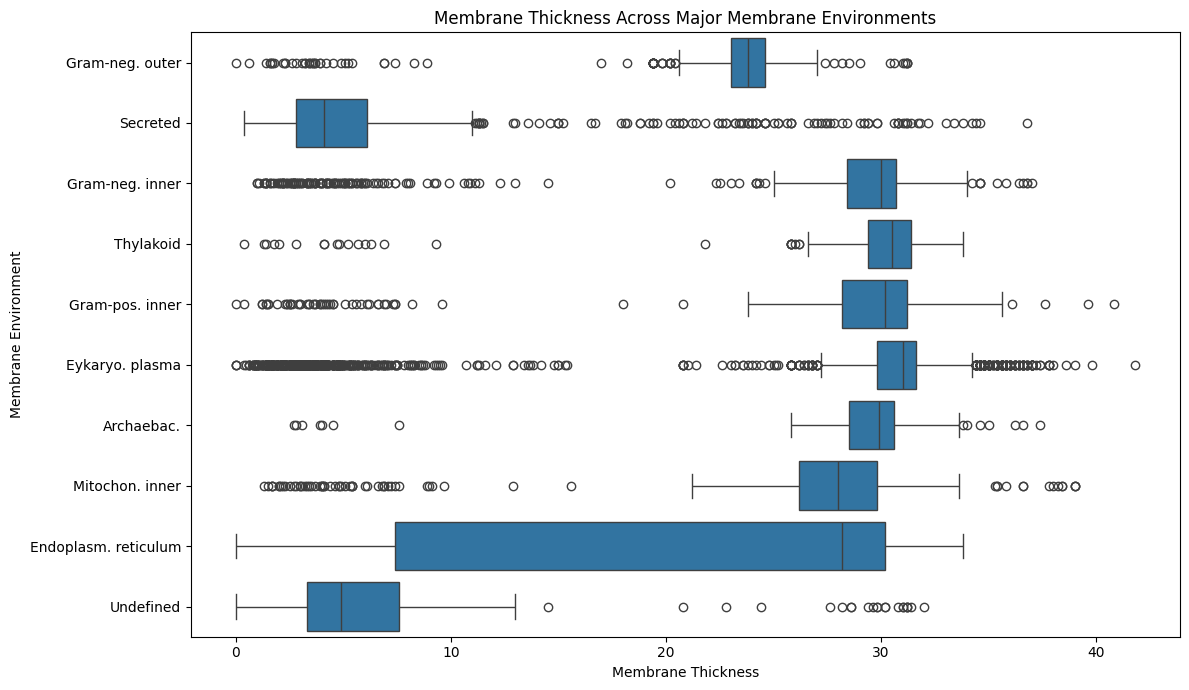

In [20]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_top_membranes,
    x="thickness",
    y="membrane_name_cache"
)

plt.title("Membrane Thickness Across Major Membrane Environments")
plt.xlabel("Membrane Thickness")
plt.ylabel("Membrane Environment")

plt.tight_layout()
plt.show()

In [21]:
thickness_summary = (
    df_top_membranes
    .groupby("membrane_name_cache", observed=True)["thickness"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
)

thickness_summary

,count,mean,median
membrane_name_cache,,,
Eykaryo. plasma,3316,27.23,31.0
Thylakoid,192,28.13,30.5
Gram-pos. inner,374,26.84,30.2
Gram-neg. inner,1251,27.42,30.0
Archaebac.,179,28.83,29.9
Endoplasm. reticulum,548,21.36,28.2
Mitochon. inner,347,25.15,28.0
Gram-neg. outer,421,22.12,23.8
Undefined,185,7.69,4.9


### Interpretation

Membrane thickness differs substantially between the major membrane environments.

Most membrane environments have median thickness values between approximately 24 and 31, with `Eykaryo. plasma` showing a median of 31.0 and `Thylakoid`, `Gram-pos. inner`, and `Gram-neg. inner` also having median values around 30.

In contrast, `Secreted` and `Undefined` structures have much lower median thickness values of 4.1 and 4.9, respectively. `Gram-neg. outer` also shows a lower median thickness of 23.8 compared with most of the other major membrane categories.

The difference between the mean and median in several groups indicates that the distributions are not symmetrical and contain substantial within-group variation. Therefore, median values are particularly useful when comparing typical membrane thickness between groups.

### 2.2.2 Protein Tilt

Protein tilt is compared across the same membrane environments. The tilt variable contains no missing values, so all records within the selected membrane groups can be included.

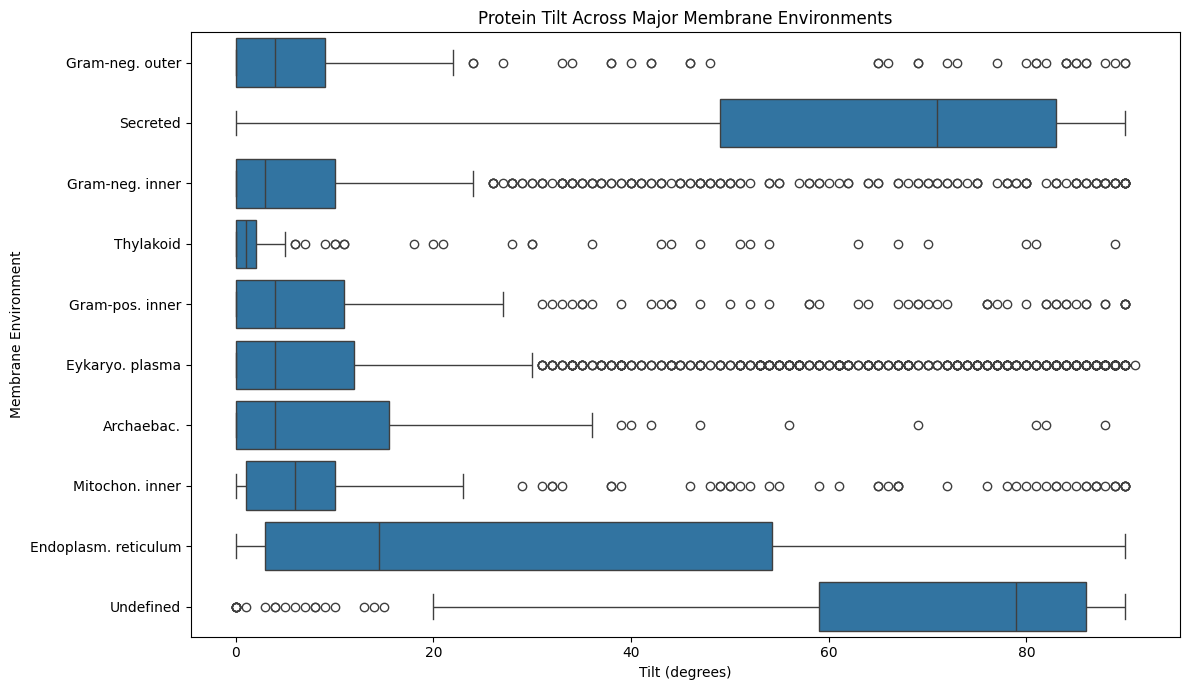

In [22]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_top_membranes,
    x="tilt",
    y="membrane_name_cache"
)

plt.title("Protein Tilt Across Major Membrane Environments")
plt.xlabel("Tilt (degrees)")
plt.ylabel("Membrane Environment")

plt.tight_layout()
plt.show()

In [23]:
tilt_summary = (
    df_top_membranes
    .groupby("membrane_name_cache", observed=True)["tilt"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
)

tilt_summary

,count,mean,median
membrane_name_cache,,,
Undefined,185,67.35,79.0
Secreted,1359,63.02,71.0
Endoplasm. reticulum,548,27.85,14.5
Mitochon. inner,347,14.10,6.0
Archaebac.,179,10.29,4.0
Eykaryo. plasma,3316,13.37,4.0
Gram-neg. outer,421,9.71,4.0
Gram-pos. inner,374,12.80,4.0
Gram-neg. inner,1251,10.61,3.0


### Interpretation

Protein tilt also varies considerably between membrane environments.

The highest median tilt values occur in the `Undefined` and `Secreted` categories, with medians of 79° and 71°, respectively. In contrast, most of the major membrane environments have much lower median tilt values. `Thylakoid` has the lowest median tilt at 1°, while `Gram-neg. inner` has a median of 3° and several other membrane categories have medians close to 4°.

The large differences between the mean and median tilt values in several groups indicate strongly skewed distributions. For example, `Eykaryo. plasma` has a median tilt of 4° but a mean of 13.37°, suggesting that a smaller number of highly tilted structures increase the mean.

Overall, the results indicate that membrane environment is associated with substantial differences in the distribution of protein tilt.

### 2.2.3 Structural Resolution

Numerical structural resolution is available for only a subset of records because some original entries contain non-numerical experimental annotations such as `NMR`.

No values are imputed. Records without a numerical resolution are excluded only from this comparison, while remaining available for analyses of other structural properties.

In [24]:
df_resolution = df_top_membranes.dropna(
    subset=["resolution_numeric"]
).copy()

print("Records in selected membrane environments:", len(df_top_membranes))
print("Records with numerical resolution:", len(df_resolution))

Records in selected membrane environments: 8172
Records with numerical resolution: 6976


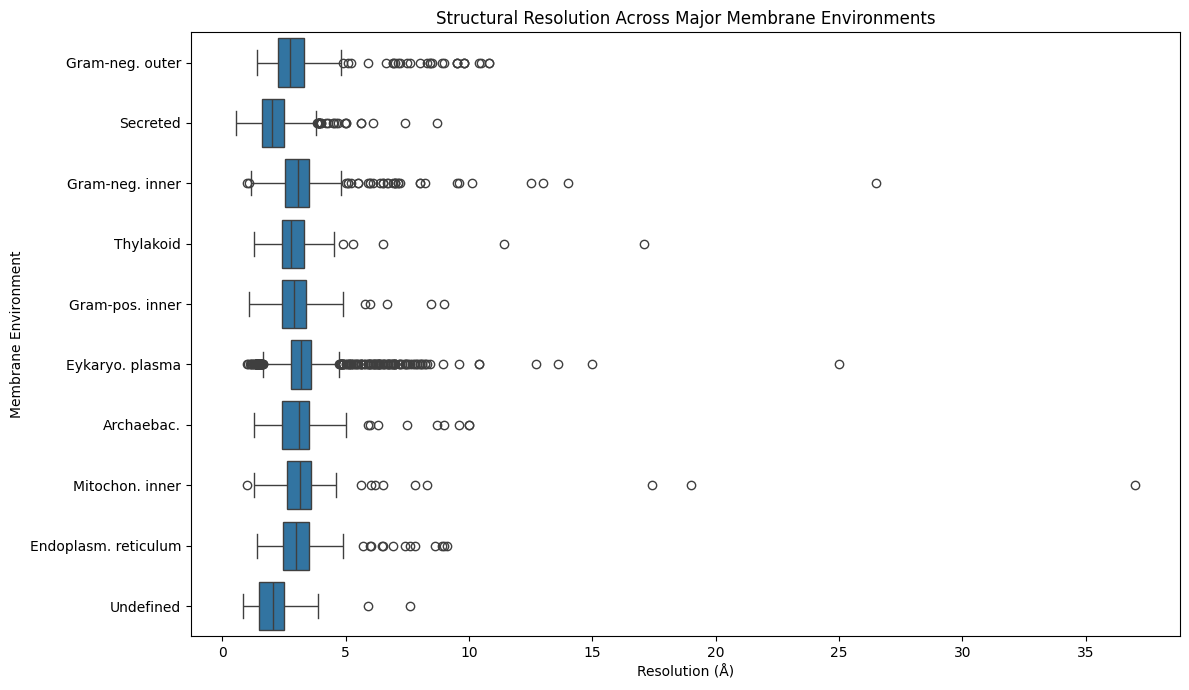

In [25]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_resolution,
    x="resolution_numeric",
    y="membrane_name_cache"
)

plt.title("Structural Resolution Across Major Membrane Environments")
plt.xlabel("Resolution (Å)")
plt.ylabel("Membrane Environment")

plt.tight_layout()
plt.show()

In [26]:
resolution_summary = (
    df_resolution
    .groupby("membrane_name_cache", observed=True)["resolution_numeric"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median")
)

resolution_summary

,count,mean,median
membrane_name_cache,,,
Secreted,632,2.12,2.00
Undefined,69,2.16,2.05
Gram-neg. outer,409,3.12,2.75
Thylakoid,182,3.05,2.80
Gram-pos. inner,363,2.94,2.92
Endoplasm. reticulum,516,3.07,3.00
Gram-neg. inner,1208,3.13,3.08
Archaebac.,177,3.23,3.10
Mitochon. inner,337,3.32,3.16


### Interpretation

Structural resolution shows smaller differences between the major membrane environments than membrane thickness or tilt.

Among records with a numerical resolution value, `Secreted` and `Undefined` structures have the lowest median resolution values at 2.00 Å and 2.05 Å, respectively. Since smaller numerical values correspond to finer structural resolution, these groups contain structures that are, on average, resolved more finely than several of the membrane-embedded categories.

The highest median values among the selected environments occur for `Eykaryo. plasma` (3.17 Å), `Mitochon. inner` (3.16 Å), and `Archaebac.` (3.10 Å).

However, numerical resolution coverage differs substantially between groups. For example, only 632 of 1,359 `Secreted` structures and 69 of 185 `Undefined` structures have a usable numerical resolution value. Resolution comparisons should therefore be interpreted with greater caution than the thickness and tilt comparisons.

### Research Question 2 Summary

The analysis shows clear differences in structural properties across the major membrane environments.

Membrane thickness and protein tilt show the strongest contrasts. Most major membrane categories have median thickness values close to 28–31 and relatively low median tilt angles. In contrast, `Secreted` and `Undefined` structures show much lower membrane thickness and substantially higher tilt values.

Structural resolution varies less strongly between membrane environments. Numerical resolution values are generally centred around approximately 2–3 Å, although the availability of numerical resolution differs between categories.

These results suggest that membrane environment is associated with distinct structural characteristics. However, the unequal number of observations within each category and differences in resolution coverage should be considered when interpreting these comparisons.

## 2.3 Structural Complexity and Structural Resolution

The third research question investigates whether structural complexity is associated with structural resolution.

The number of membrane-spanning segments (`subunit_segments`) is used as an indicator of structural complexity, while `resolution_numeric` represents the numerical structural resolution.

Records without a numerical resolution value are excluded from this analysis. Missing values are not imputed.

In [27]:
complexity_resolution = df[
    ["subunit_segments", "resolution_numeric"]
].dropna()

complexity_resolution.shape

(7575, 2)

In [28]:
complexity_resolution.describe()

,subunit_segments,resolution_numeric
count,7575.000000,7575.000000
mean,16.496766,3.064330
std,19.237504,1.262766
min,0.000000,0.540000
25%,6.000000,2.440000
50%,12.000000,3.000000
75%,24.000000,3.500000
max,389.000000,37.000000


In [29]:
complexity_resolution.sort_values(
    "subunit_segments",
    ascending=False
).head(10)

,subunit_segments,resolution_numeric
5042,389,2.74
4809,203,2.90
4810,201,3.30
4406,190,3.48
6948,168,2.50
6585,163,7.80
6928,163,3.89
6922,157,4.50
1305,154,19.00
6509,150,3.40


### Correlation Between Structural Complexity and Resolution

Both Pearson and Spearman correlations are calculated using all available observations.

Pearson correlation measures the strength of a linear relationship, while Spearman correlation evaluates whether the variables have a monotonic relationship and is less sensitive to extreme values.

In [30]:
pearson_corr = complexity_resolution[
    "subunit_segments"
].corr(
    complexity_resolution["resolution_numeric"],
    method="pearson"
)

spearman_corr = complexity_resolution[
    "subunit_segments"
].corr(
    complexity_resolution["resolution_numeric"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.197
Spearman correlation: 0.445


### Structural Complexity vs Structural Resolution

The scatter plot below shows all 7,575 structures with both segment-count and numerical-resolution data. All valid observations, including extreme values, are retained.

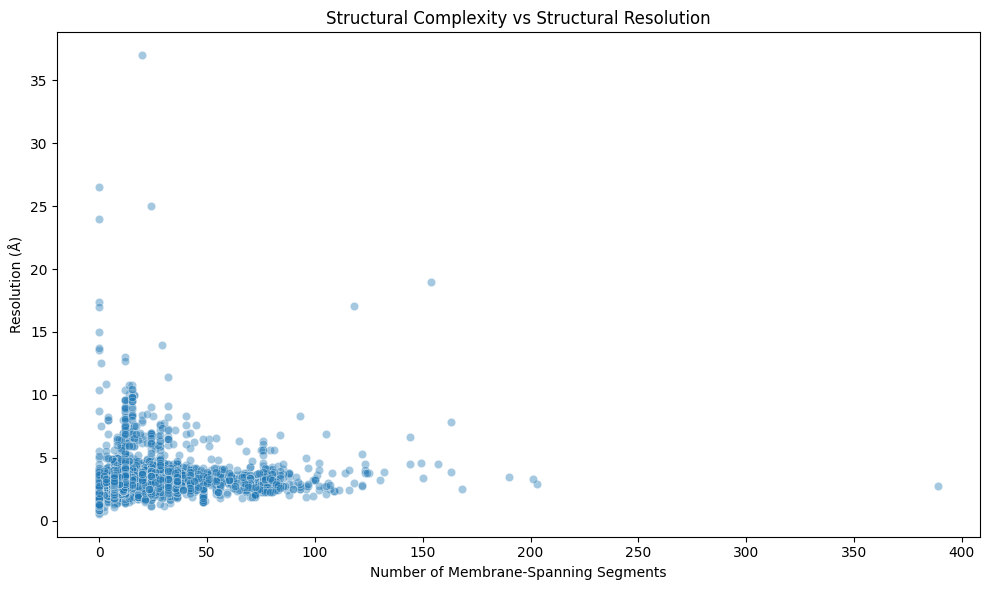

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=complexity_resolution,
    x="subunit_segments",
    y="resolution_numeric",
    alpha=0.4
)

plt.title("Structural Complexity vs Structural Resolution")
plt.xlabel("Number of Membrane-Spanning Segments")
plt.ylabel("Resolution (Å)")

plt.tight_layout()
plt.show()

In [33]:
segments_95 = complexity_resolution["subunit_segments"].quantile(0.95)
resolution_95 = complexity_resolution["resolution_numeric"].quantile(0.95)

print(f"95th percentile of subunit segments: {segments_95}")
print(f"95th percentile of resolution: {resolution_95:.2f} Å")

95th percentile of subunit segments: 52.0
95th percentile of resolution: 4.30 Å


In [34]:
central_data = complexity_resolution[
    (complexity_resolution["subunit_segments"] <= segments_95) &
    (complexity_resolution["resolution_numeric"] <= resolution_95)
]

central_data.shape

(6851, 2)

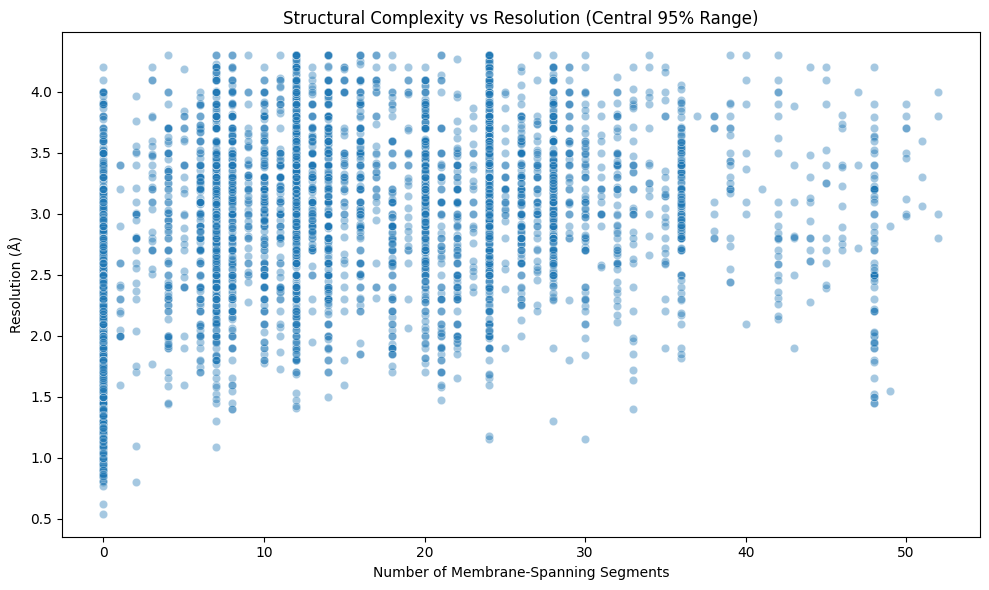

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=central_data,
    x="subunit_segments",
    y="resolution_numeric",
    alpha=0.4
)

plt.title("Structural Complexity vs Resolution (Central 95% Range)")
plt.xlabel("Number of Membrane-Spanning Segments")
plt.ylabel("Resolution (Å)")

plt.tight_layout()
plt.show()

### Interpretation

The relationship between structural complexity and structural resolution is positive, but its strength depends on the correlation measure used.

The Pearson correlation coefficient is 0.197, indicating only a weak positive linear relationship between the number of membrane-spanning segments and numerical resolution. In contrast, the Spearman correlation coefficient is 0.445, indicating a moderate positive monotonic relationship.

The stronger Spearman correlation suggests that resolution tends to increase as the number of membrane-spanning segments increases, but the relationship is not strongly linear and is influenced by the skewed distributions and extreme observations.

Since higher numerical resolution values in Å correspond to lower structural detail, this result suggests that more structurally complex membrane proteins tend to be resolved at somewhat lower resolution.

The full dataset contains several extreme observations, with segment counts reaching 389 and resolution values reaching 37 Å. To improve visual interpretation, a second scatter plot was therefore restricted to observations within the 95th percentile of both variables (≤52 membrane-spanning segments and ≤4.30 Å resolution). This visualization contains 6,851 observations and shows the main concentration of the dataset without removing extreme values from the correlation calculations.

### Research Question 3 Summary

Structural complexity shows a moderate monotonic association with structural resolution, although the linear relationship is weak. Structures containing more membrane-spanning segments generally tend toward higher numerical resolution values, corresponding to lower structural detail.

The difference between the Pearson and Spearman correlations indicates that this relationship is not simply linear and that the distribution of the variables and extreme observations affect the association. Therefore, structural complexity appears to be related to achievable structural resolution, but it is unlikely to be the only factor influencing resolution.

---

## 2.4 Relationships Between Numerical Structural Properties

The fourth research question examines relationships between the main numerical structural properties in the dataset.

The analysis focuses on membrane thickness, protein tilt, number of membrane-spanning segments, Gibbs free energy, and structural resolution.

A correlation matrix is used to identify positive and negative associations between these variables. Missing values are handled using the available observations for each pair of variables rather than being imputed.

In [36]:
structural_variables = df[
    [
        "thickness",
        "tilt",
        "subunit_segments",
        "gibbs",
        "resolution_numeric"
    ]
]

structural_variables.describe()

,thickness,tilt,subunit_segments,gibbs,resolution_numeric
count,8914.000000,8914.000000,8914.000000,8914.000000,7575.000000
mean,22.220989,23.621943,14.134283,-89.151604,3.064330
std,12.084034,30.730578,18.642546,88.522280,1.262766
min,0.000000,0.000000,0.000000,-691.000000,0.540000
25%,6.500000,1.000000,0.000000,-126.900000,2.440000
50%,29.650000,7.000000,10.000000,-71.550000,3.000000
75%,31.000000,44.000000,21.000000,-9.600000,3.500000
max,41.800000,91.000000,389.000000,165.500000,37.000000


### Pearson Correlation

Pearson correlation is first used to examine linear relationships between the numerical structural properties.

In [37]:
pearson_matrix = structural_variables.corr(method="pearson")

pearson_matrix.round(3)

,thickness,tilt,subunit_segments,gibbs,resolution_numeric
thickness,1.000,-0.875,0.473,-0.622,0.350
tilt,-0.875,1.000,-0.501,0.609,-0.319
subunit_segments,0.473,-0.501,1.000,-0.841,0.197
gibbs,-0.622,0.609,-0.841,1.000,-0.222
resolution_numeric,0.350,-0.319,0.197,-0.222,1.000


### Spearman Correlation

Spearman correlation is also calculated because several structural variables have skewed distributions and extreme observations. This allows monotonic relationships to be identified even when they are not strongly linear.

In [38]:
spearman_matrix = structural_variables.corr(method="spearman")

spearman_matrix.round(3)

,thickness,tilt,subunit_segments,gibbs,resolution_numeric
thickness,1.000,-0.634,0.590,-0.694,0.403
tilt,-0.634,1.000,-0.813,0.807,-0.398
subunit_segments,0.590,-0.813,1.000,-0.925,0.445
gibbs,-0.694,0.807,-0.925,1.000,-0.448
resolution_numeric,0.403,-0.398,0.445,-0.448,1.000


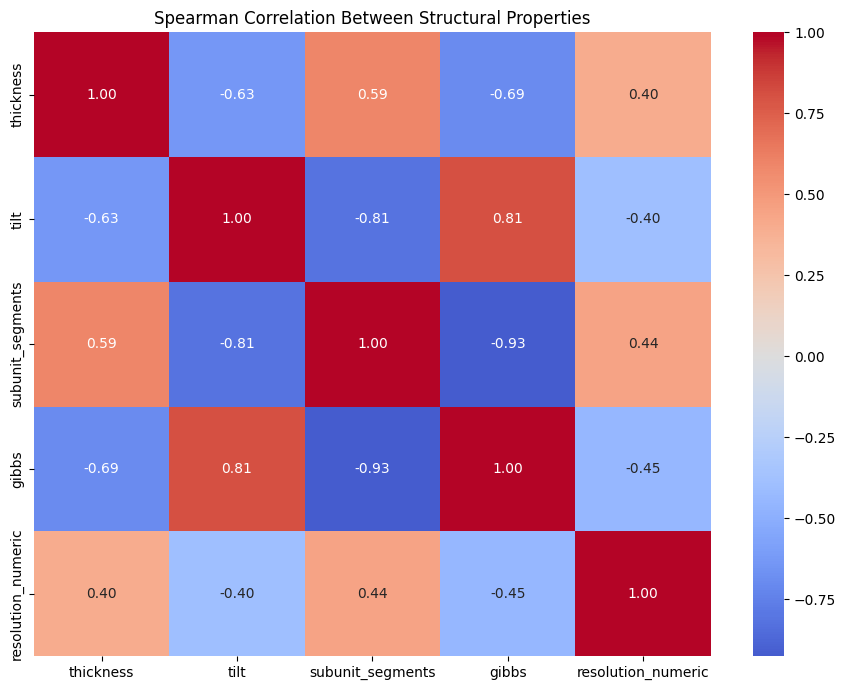

In [39]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Between Structural Properties")

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis reveals several meaningful relationships between the structural properties in the dataset.

The strongest Spearman correlation is observed between `subunit_segments` and `gibbs` (ρ = -0.925), indicating a very strong negative monotonic relationship. Structures with a greater number of membrane-spanning segments tend to have more negative Gibbs free-energy values.

Protein tilt also shows strong relationships with structural complexity and Gibbs free energy. Tilt is strongly negatively correlated with `subunit_segments` (ρ = -0.813) and strongly positively correlated with `gibbs` (ρ = 0.807).

Membrane thickness is moderately positively associated with the number of membrane-spanning segments (ρ = 0.590) and negatively associated with both tilt (ρ = -0.634) and Gibbs free energy (ρ = -0.694).

Structural resolution shows weaker relationships with the other variables. Its strongest Spearman associations are with Gibbs free energy (ρ = -0.448) and the number of membrane-spanning segments (ρ = 0.445). This supports the earlier finding that structural complexity is moderately associated with numerical resolution.

Several relationships are stronger using Spearman than Pearson correlation. This indicates that some associations are monotonic but not strongly linear and may also be affected by skewed distributions and extreme observations.

### Research Question 4 Summary

The numerical structural properties are not independent of one another. The strongest relationship is between the number of membrane-spanning segments and Gibbs free energy, followed by strong associations between protein tilt, structural complexity, and Gibbs free energy.

Membrane thickness also shows meaningful relationships with several structural properties, while structural resolution has comparatively weaker associations.

Overall, the Spearman correlation matrix reveals stronger relationships than the Pearson matrix for several variable pairs, suggesting that monotonic and potentially non-linear patterns are important in this dataset. These correlations describe associations and should not be interpreted as evidence of causal relationships.

## Section 2 Conclusion

The exploratory analysis identified clear patterns in the membrane protein dataset. The dataset is unevenly represented across both membrane environments and protein families, with eukaryotic plasma membrane proteins and family A GPCRs being particularly prominent.

Structural properties also vary across membrane environments. Membrane thickness and protein tilt show substantial differences between groups, while structural resolution varies less strongly. Structural complexity, represented by the number of membrane-spanning segments, shows a moderate monotonic association with numerical resolution, suggesting that more complex structures tend to be resolved at somewhat lower structural detail.

The correlation analysis further shows that several structural properties are strongly associated. In particular, the number of membrane-spanning segments is strongly negatively correlated with Gibbs free energy, while protein tilt, membrane thickness, and structural complexity also show meaningful relationships.

Overall, the analysis demonstrates that membrane environment, structural complexity, and other structural properties are associated with distinct patterns within the dataset. These findings describe statistical associations and should not be interpreted as evidence of causal relationships.

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
